# VNL 2024 Men — Data Analysis Notebook
> **Volleyball Nations League 2024 · Men's Tournament**  
> Data: 16 teams · 304 players · 7 statistical categories

---

## Sections
1. Setup & Data Loading
2. Team Performance
3. Best Attacker
4. Best Libero (Defence)
5. Best Middle Blocker
6. Best Server
7. Team Synergy & Balance
8. Player Demographics

In [10]:
import os
import sys

print("Current working directory:", os.getcwd())
print("Files here:", os.listdir())
print("Python path:", sys.path[:3])

Current working directory: C:\Users\Sunil\Vnl_analysis
Files here: ['.ipynb_checkpoints', 'src', 'VNL2024Men_Attackers.csv', 'VNL2024Men_Blockers.csv', 'VNL2024Men_Diggers.csv', 'VNL2024Men_Players.csv', 'VNL2024Men_Receivers.csv', 'VNL2024Men_Scorers.csv', 'VNL2024Men_Servers.csv', 'VNL2024_Analysis.ipynb']
Python path: ['C:\\Users\\Sunil', 'C:\\Users\\Sunil', 'C:\\Users\\Sunil']


In [12]:
import sys
import os

# Get project root (adjust depending on notebook location)
PROJECT_ROOT = os.path.abspath("..")   # use "." if notebook is in root folder

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.data_loader import build_master, team_summary
from src.rankings import (
    all_rankings,
    score_attackers,
    score_liberos,
    score_middle_blockers,
    score_servers
)
from src.analysis import (
    team_synergy,
    player_contribution,
    attack_risk_profile,
    age_analysis,
    height_analysis
)

%matplotlib inline

plt.rcParams["figure.dpi"] = 130
plt.rcParams["figure.facecolor"] = "white"

master = build_master()
team_df = team_summary(master)
rankings = all_rankings(master)

print(f"Master: {master.shape}")
master.head(3)

Master: (304, 35)


,Team,Name,Position,Height,Birth_Year,Tot_Pts,Tot_Atk,Tot_Block,Tot_Serve,Pt_Attack,...,Err_Receive,Att_Receive,MAvg_Receive,p_Receive,Pt_Serve,Err_Serve,Att_Serve,MAvg_Serve,p_Serve,Age
0,ARG,Armoa Morel,OH,195,2002,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.00,22
1,ARG,Conte,OH,197,1989,121.0,101.0,11.0,9.0,101.0,...,4.0,142.0,2.62,18.89,9.0,23.0,86.0,0.69,7.63,35
2,ARG,Danani,L,176,1995,0.0,0.0,0.0,0.0,0.0,...,9.0,171.0,4.08,22.75,0.0,0.0,2.0,0.00,0.00,29


## 1. Team Performance

In [13]:
team_df

,Team,Total_Pts,Total_Atk,Total_Block,Total_Serve,Players,Rank
0,FRA,1042.0,820.0,140.0,82.0,17,1
1,SLO,979.0,767.0,106.0,106.0,18,2
2,JPN,926.0,760.0,85.0,81.0,18,3
3,POL,887.0,673.0,136.0,78.0,25,4
4,BRA,865.0,687.0,114.0,64.0,17,5
5,CAN,851.0,670.0,112.0,69.0,16,6
6,ARG,848.0,662.0,133.0,53.0,18,7
7,CUB,816.0,647.0,115.0,54.0,14,8
8,ITA,788.0,621.0,104.0,63.0,24,9
9,NED,777.0,591.0,97.0,89.0,17,10


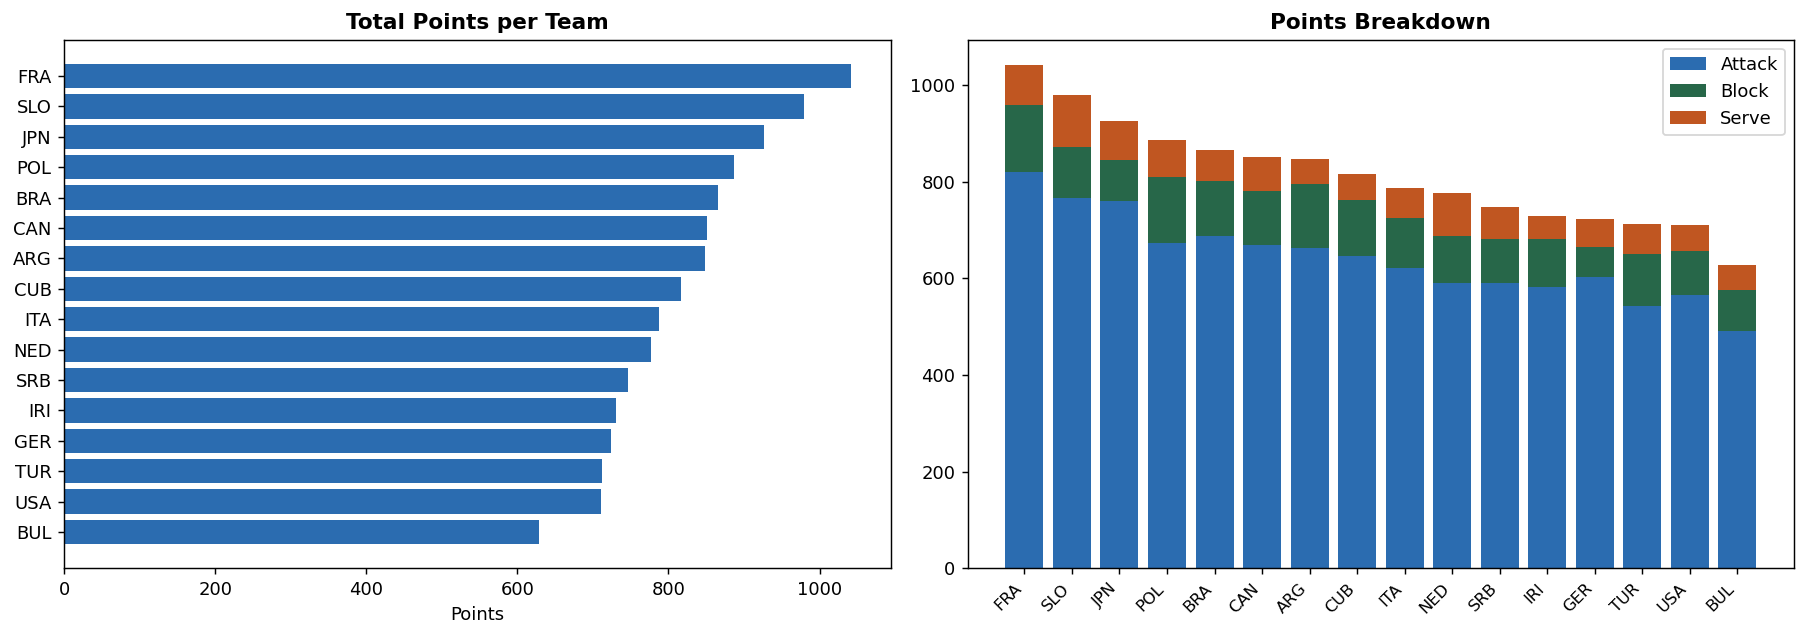

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total points
ax = axes[0]
sorted_t = team_df.sort_values('Total_Pts')
ax.barh(sorted_t['Team'], sorted_t['Total_Pts'], color='#2B6CB0')
ax.set_title('Total Points per Team', fontweight='bold')
ax.set_xlabel('Points')

# Breakdown stacked
ax = axes[1]
x = range(len(team_df))
ax.bar(x, team_df['Total_Atk'],   label='Attack',  color='#2B6CB0')
ax.bar(x, team_df['Total_Block'], bottom=team_df['Total_Atk'], label='Block', color='#276749')
ax.bar(x, team_df['Total_Serve'], bottom=team_df['Total_Atk']+team_df['Total_Block'], label='Serve', color='#C05621')
ax.set_xticks(list(x))
ax.set_xticklabels(team_df['Team'], rotation=45, ha='right', fontsize=9)
ax.legend()
ax.set_title('Points Breakdown', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Best Attackers

In [15]:
rankings['attackers'].head(10)

,Name,Team,Position,Height,Age,Pt_Attack,Err_Attack,Att_Attack,p_Attack,MAvg_Attack,attack_score
0,T. Stern,SLO,O,200,29,265.0,68.0,153.0,54.53,17.67,84.41
1,Nimir,NED,O,201,32,235.0,81.0,138.0,51.76,19.58,79.87
2,Maar,CAN,OH,201,30,194.0,59.0,150.0,48.14,14.92,66.29
3,Yant,CUB,OH,204,23,167.0,49.0,98.0,53.18,13.92,61.68
4,Amin,IRI,O,202,28,167.0,49.0,121.0,49.55,13.92,60.59
5,Cebulj,SLO,OH,202,32,179.0,63.0,149.0,45.78,11.93,59.69
6,Ishikawa,JPN,OH,192,29,155.0,49.0,96.0,51.67,14.09,59.14
7,Lopez,CUB,OH,189,27,154.0,54.0,94.0,50.99,12.83,57.46
8,Patry,FRA,O,207,28,164.0,41.0,123.0,50.00,10.93,57.11
9,Nishida,JPN,O,187,24,156.0,41.0,88.0,54.74,10.40,56.48


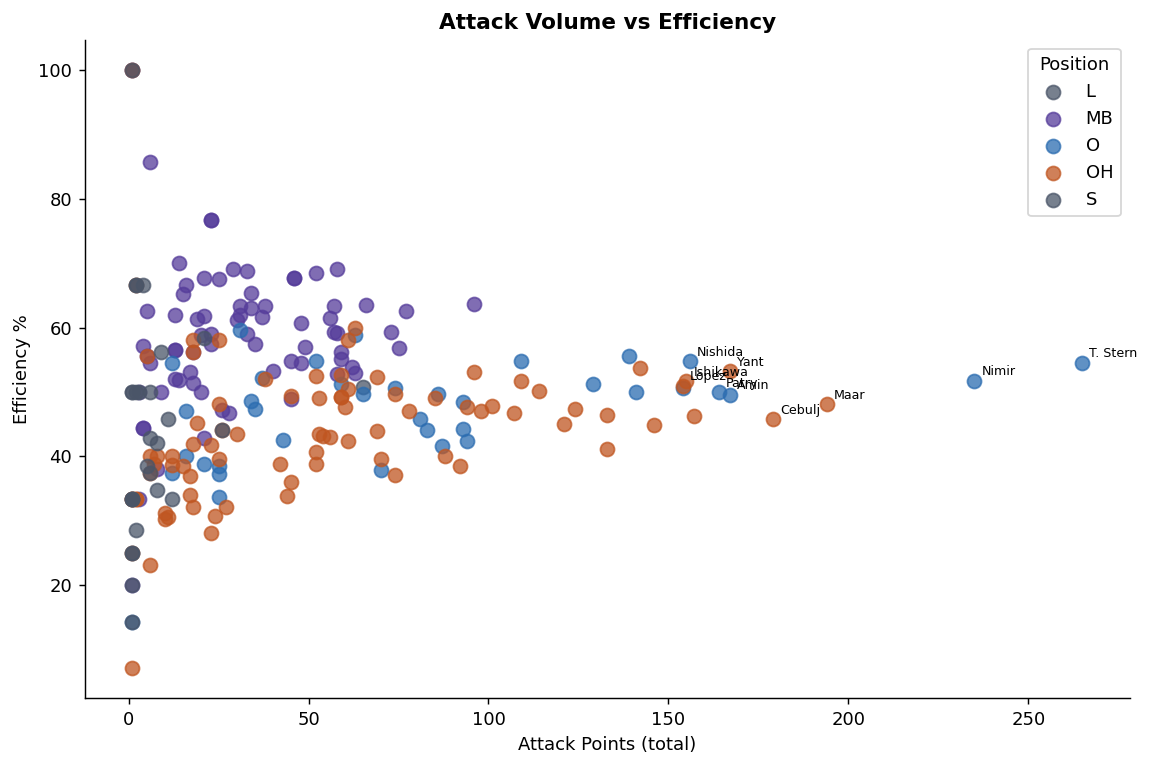

In [16]:
atk = rankings['attackers']

fig, ax = plt.subplots(figsize=(9, 6))
pos_color = {'O':'#2B6CB0', 'OH':'#C05621', 'MB':'#553C9A'}
for pos, grp in atk.groupby('Position'):
    ax.scatter(grp['Pt_Attack'], grp['p_Attack'],
               c=pos_color.get(pos, '#4A5568'), label=pos, s=60, alpha=0.75)

for _, r in atk.head(10).iterrows():
    ax.annotate(r['Name'], (r['Pt_Attack'], r['p_Attack']),
                textcoords='offset points', xytext=(4,3), fontsize=7)

ax.set_xlabel('Attack Points (total)')
ax.set_ylabel('Efficiency %')
ax.set_title('Attack Volume vs Efficiency', fontweight='bold')
ax.legend(title='Position')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 3. Best Libero (Defence)

In [17]:
rankings['liberos']

,Name,Team,Height,Age,Sf_Dig,Err_Dig,p_Dig,Sf_Receive,Err_Receive,p_Receive,libero_score
0,Kovacic,SLO,186,32,116.0,63.0,60.10,78.0,21.0,25.74,103.35
1,Danani,ARG,176,29,123.0,58.0,65.43,53.0,9.0,22.75,96.85
2,Grebennikov,FRA,188,34,114.0,65.0,60.00,61.0,12.0,26.07,95.82
3,Thales,BRA,190,35,92.0,33.0,69.70,65.0,15.0,26.97,91.80
4,Arman,IRI,180,32,66.0,33.0,59.46,90.0,16.0,33.33,90.24
5,Roman Garcia,CUB,175,31,76.0,43.0,61.29,64.0,31.0,25.20,81.95
6,Bozhilov,BUL,190,36,67.0,41.0,55.83,63.0,11.0,32.14,78.39
7,Andringa,NED,192,34,73.0,38.0,62.39,52.0,16.0,21.58,75.19
8,Yamamoto,JPN,171,30,94.0,47.0,64.38,33.0,15.0,16.50,75.06
9,E. Shoji,USA,184,35,68.0,24.0,70.10,40.0,12.0,30.53,73.39


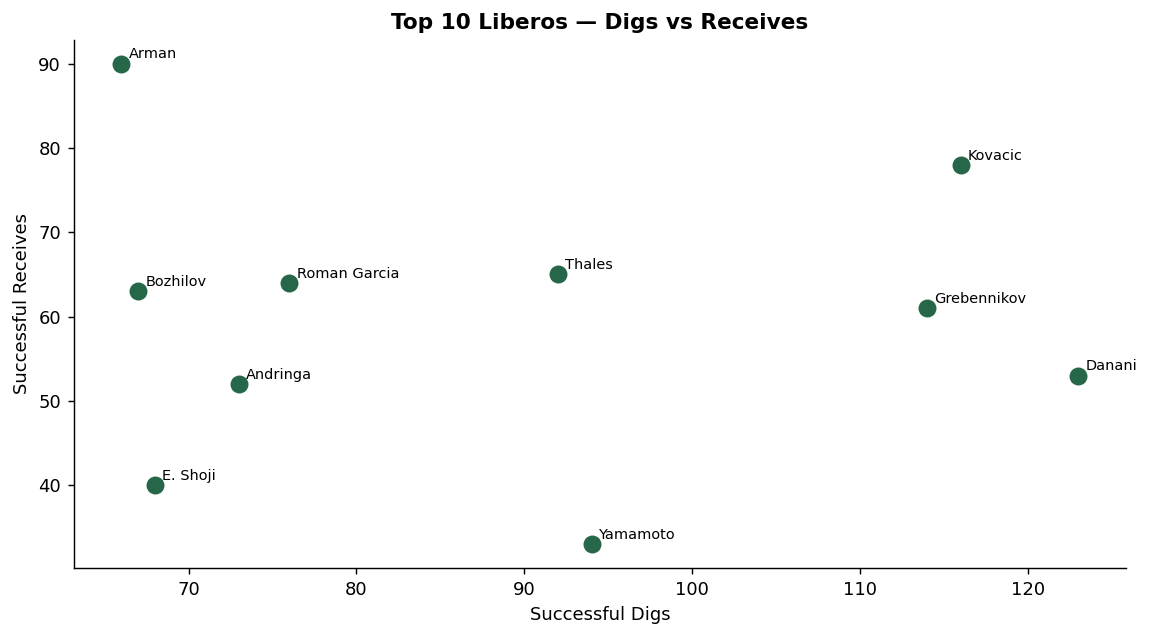

In [18]:
lib = rankings['liberos'].head(10)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(lib['Sf_Dig'], lib['Sf_Receive'], s=80, color='#276749')
for _, r in lib.iterrows():
    ax.annotate(r['Name'], (r['Sf_Dig'], r['Sf_Receive']),
                textcoords='offset points', xytext=(4,3), fontsize=8)
ax.set_xlabel('Successful Digs')
ax.set_ylabel('Successful Receives')
ax.set_title('Top 10 Liberos — Digs vs Receives', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Best Middle Blockers

In [19]:
rankings['middle_blockers'].head(10)

,Name,Team,Height,Age,Pt_Block,Err_Block,p_Block,Pt_Attack,p_Attack,mb_score
0,Concepcion,CUB,202,27,24.0,70.0,-33.09,96.0,63.58,53.52
1,Loser Bruno,ARG,198,27,34.0,59.0,-17.86,75.0,56.82,50.86
2,Kozamernik,SLO,204,29,26.0,68.0,-26.58,73.0,59.35,46.77
3,Flavio,BRA,199,31,33.0,68.0,-23.03,57.0,63.33,46.27
4,Le Goff,FRA,206,32,34.0,51.0,-12.32,59.0,55.14,45.73
5,Zerba,ARG,203,25,30.0,47.0,-13.18,62.0,53.91,44.38
6,Pajenk,SLO,203,38,16.0,47.0,-23.85,77.0,62.60,43.62
7,Grozdanov,BUL,208,26,29.0,40.0,-8.87,58.0,52.73,42.45
8,Simon,CUB,208,37,22.0,55.0,-28.70,58.0,69.05,42.21
9,Parkinson,NED,203,33,19.0,30.0,-13.10,66.0,63.46,41.99


## 5. Team Synergy & Balance

In [20]:
syn = team_synergy(team_df)
syn

,Team,Total_Pts,atk_share,block_share,serve_share,balance_score,dominant_phase
3,POL,887.0,0.759,0.153,0.088,69.801,Atk
9,NED,777.0,0.761,0.125,0.115,69.784,Atk
13,TUR,712.0,0.761,0.152,0.087,69.628,Atk
15,BUL,628.0,0.782,0.134,0.084,68.221,Atk
1,SLO,979.0,0.783,0.108,0.108,68.172,Atk
6,ARG,848.0,0.781,0.157,0.062,68.136,Atk
0,FRA,1042.0,0.787,0.134,0.079,67.844,Atk
5,CAN,851.0,0.787,0.132,0.081,67.833,Atk
8,ITA,788.0,0.788,0.132,0.080,67.775,Atk
10,SRB,747.0,0.791,0.120,0.088,67.600,Atk


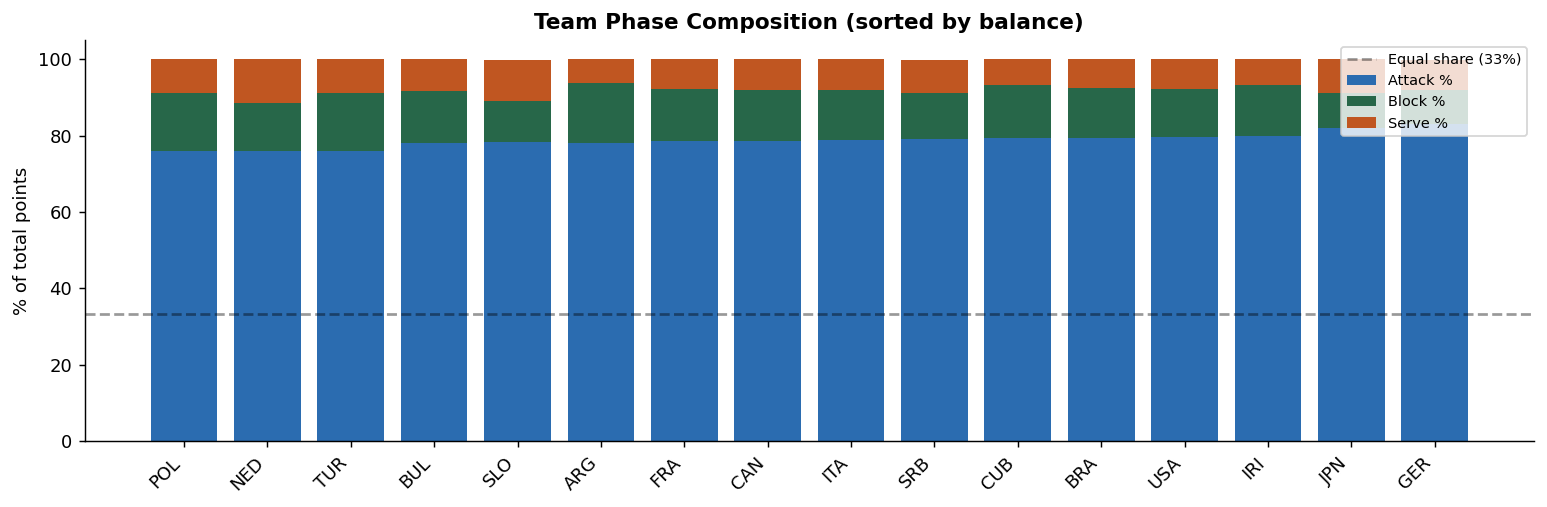

In [21]:
# Stacked area-style phase share comparison
syn_sorted = syn.sort_values('balance_score', ascending=False).reset_index(drop=True)
x = range(len(syn_sorted))

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, syn_sorted['atk_share']*100,   label='Attack %',  color='#2B6CB0')
ax.bar(x, syn_sorted['block_share']*100, bottom=syn_sorted['atk_share']*100,
       label='Block %', color='#276749')
ax.bar(x, syn_sorted['serve_share']*100,
       bottom=(syn_sorted['atk_share']+syn_sorted['block_share'])*100,
       label='Serve %', color='#C05621')
ax.axhline(100/3, color='black', linestyle='--', alpha=0.4, label='Equal share (33%)')
ax.set_xticks(list(x))
ax.set_xticklabels(syn_sorted['Team'], rotation=45, ha='right')
ax.set_ylabel('% of total points')
ax.set_title('Team Phase Composition (sorted by balance)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Player Demographics

In [22]:
print('Average age by position:')
print(age_analysis(master)['avg_age_by_pos'])
print()
print('Height by position:')
print(height_analysis(master).to_string(index=False))

Average age by position:
Position
OH    26.9
O     27.2
MB    27.9
L     28.2
S     29.1
Name: Age, dtype: float64

Height by position:
Position  avg_height  max_height  min_height  n
       L       182.7         198         171 35
      MB       203.5         214         195 82
       O       201.0         211         187 41
      OH       197.4         209         185 97
       S       191.6         207         175 49


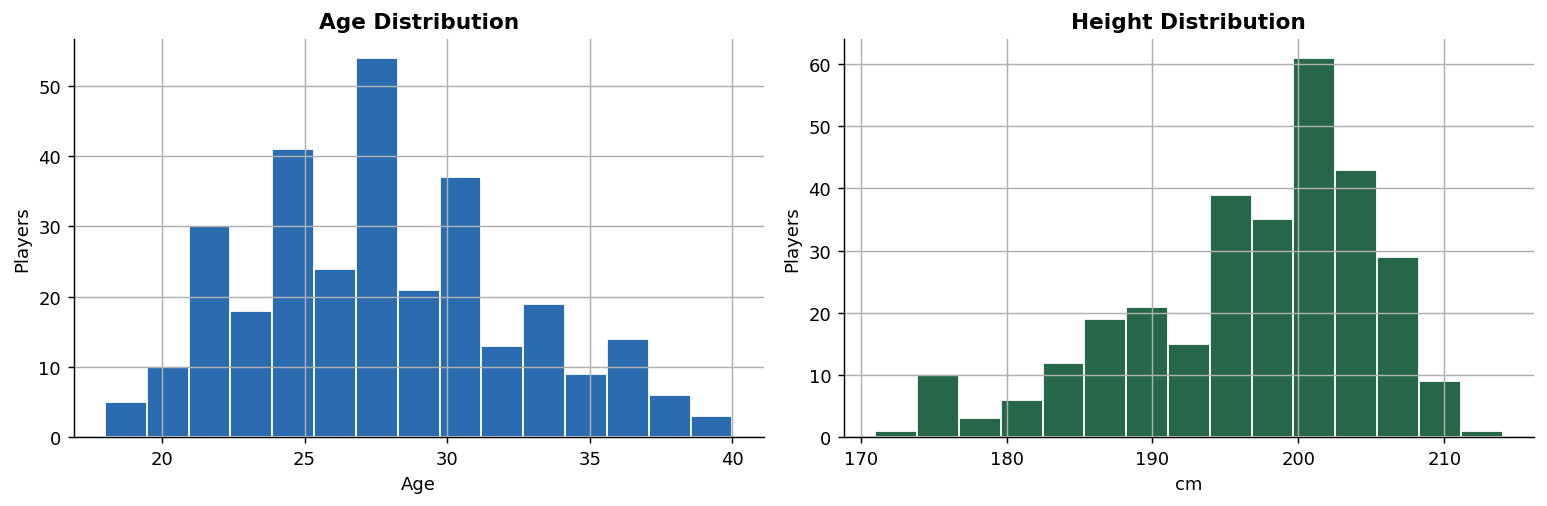

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
master['Age'].hist(bins=15, ax=ax, color='#2B6CB0', edgecolor='white')
ax.set_title('Age Distribution', fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Players')
ax.spines[['top','right']].set_visible(False)

ax = axes[1]
master['Height'].hist(bins=15, ax=ax, color='#276749', edgecolor='white')
ax.set_title('Height Distribution', fontweight='bold')
ax.set_xlabel('cm'); ax.set_ylabel('Players')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()